# Medical Anomaly Detection on discharge summaries — **Laya** vs **Jev**

## 1. Install & keys

In [1]:
!pip install -q -U laya requests pandas scikit-learn matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.7/79.7 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.5/214.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 46.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
cudf

In [3]:
import os, getpass
for k in ["OPENROUTER_API_KEY"]:
    try:
        from google.colab import userdata
        os.environ[k] = userdata.get(k) or ""
    except Exception:
        pass
    if not os.environ.get(k):
        os.environ[k] = getpass.getpass(f"{k}: ")
OR_KEY  = os.environ["OPENROUTER_API_KEY"]
OR_BASE = "https://openrouter.ai/api/v1"
print("Keys loaded")


Keys loaded


In [4]:
os.environ["USE_TF"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import json, math, time
import numpy as np, pandas as pd
from concurrent.futures import ThreadPoolExecutor
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "no GPU (Laya will be ~10x slower)")


torch 2.11.0+cu128 | device: cuda | Tesla T4


## 2. Config

In [5]:
JEV_MODEL   = "typesafe/jev-1.13"     # OpenRouter model id
MAX_WORKERS = 8                       # parallel Jev calls
N_ROWS      = None                    # cap rows (bounds Jev cost). None = all

# Laya
LAYA_CHECKPOINT  = "english"          # "english" (512 ctx, strongest on English -> chunked) | "multilingual" (8k ctx, one pass, weaker on English)
CHUNK_WORDS      = 200                # ~300 tokens; clinical text tokenizes densely
CHUNK_OVERLAP    = 40
LAYA_BATCH       = 16
LAYA_NOUL_LABELS = True               # Laya docs: its English checkpoint can follow the literal "true"/"false" noul labels instead of the text;
                                      # the documented workaround shows the model "A"/"B" instead. The returned value is still P(true). Set False to send byte-identical questions.

# Jev
JEV_CHUNK       = False               # False = whole summary in one call (Jev reads long docs). True = same chunking as Laya, for a like-for-like read
JEV_PRICE_PER_M = 0.042               # USD / 1M tokens, fallback only if the API omits usage.cost


## 3. Shared question design



In [6]:
SEVERITY = {
    "none":     "No clinical concern; expected for this patient.",
    "low":      "Minor deviation; routine follow-up.",
    "moderate": "Clinically relevant; review within hours.",
    "high":     "Serious; prompt clinician review needed.",
    "critical": "Potentially life-threatening; immediate action.",
}
SEV_NAMES = list(SEVERITY)

ANOMALY_TYPES = {
    "none":                        "Safe, appropriate discharge; summary is complete and internally consistent.",
    "unsafe_discharge":            "Patient discharged while clinically unstable or with an unaddressed dangerous finding.",
    "medication_error":            "Discharge medication list has a wrong dose/frequency, dangerous omission, duplication, allergy conflict or contraindication.",
    "documentation_inconsistency": "Summary contradicts itself (side, dates, allergies, diagnoses vs treatment).",
    "missing_follow_up":           "A significant finding or pending result has no follow-up plan or responsible owner.",
}

QUESTIONS = {
    "is_anomaly": {"type": "noul", "instructions":
        "This discharge summary contains a patient-safety problem: unsafe discharge, medication error, "
        "internal contradiction, or a significant finding/pending result without follow-up. "
        "A complete, consistent summary of an appropriate discharge is NOT anomalous. "
        "Values at the patient's documented baseline are NOT anomalous."},
    "anomaly_type": {"type": "choice", "instructions": "Which category best describes this event?",
                     "criteria": ANOMALY_TYPES},
    "severity": {"type": "score", "instructions": "How clinically severe is this event for this patient?",
                 "criteria": [f"{k}: {v}" for k, v in SEVERITY.items()]},
    "urgent_review": {"type": "noul", "instructions":
        "A clinician should act on this discharge summary today (e.g. recall the patient or correct the prescription)."},
}

import copy
LAYA_QUESTIONS = copy.deepcopy(QUESTIONS)
if LAYA_NOUL_LABELS:
    for qq in LAYA_QUESTIONS.values():
        if qq["type"] == "noul":
            qq["labels"] = {"true": "A", "false": "B"}   # model-facing text only; answer is still P(true)

def as_text(state): return state if isinstance(state, str) else json.dumps(state)
print(json.dumps(QUESTIONS, indent=2)[:700], "...")


{
  "is_anomaly": {
    "type": "noul",
    "instructions": "This discharge summary contains a patient-safety problem: unsafe discharge, medication error, internal contradiction, or a significant finding/pending result without follow-up. A complete, consistent summary of an appropriate discharge is NOT anomalous. Values at the patient's documented baseline are NOT anomalous."
  },
  "anomaly_type": {
    "type": "choice",
    "instructions": "Which category best describes this event?",
    "criteria": {
      "none": "Safe, appropriate discharge; summary is complete and internally consistent.",
      "unsafe_discharge": "Patient discharged while clinically unstable or with an unaddressed dan ...


## 4. Load discharge summaries from CSV



In [18]:
from google.colab import files
print("Upload discharge_summaries.csv (Cancel = use built-in demo set) …")
up = files.upload()
if up: CSV_PATH = next(iter(up))


ds = pd.read_csv(CSV_PATH); SOURCE = CSV_PATH
if "domain" in ds.columns: ds = ds[ds["domain"].astype(str).str.lower() == "discharge"]
low = {c.lower(): c for c in ds.columns}
TEXT_COL  = next((low[c] for c in ["discharge_summary","discharge_text","text","summary","note"] if c in low), None) \
            or ds.select_dtypes("object").apply(lambda s: s.astype(str).str.len().mean()).idxmax()
LABEL_COL = next((low[c] for c in ["label","anomaly","is_anomaly","target"] if c in low), None)
TYPE_COL  = next((low[c] for c in ["exp_type","anomaly_type","type"] if c in low), None)

ds = ds.dropna(subset=[TEXT_COL]).reset_index(drop=True)
if N_ROWS: ds = ds.head(N_ROWS)
HAS_LABELS = LABEL_COL is not None

def case(text, label=None, exp_type=None):
    return {"state": {"discharge_summary": str(text).strip()},
            "label": (1 if str(label).strip().lower() in {"1","true","yes","y","anomaly"} else 0) if label is not None else np.nan,
            "exp_type": (str(exp_type).strip().lower() if exp_type is not None else None)}

CASES = [case(r[TEXT_COL], r[LABEL_COL] if HAS_LABELS else None, r[TYPE_COL] if TYPE_COL else None) for _, r in ds.iterrows()]
cases_df = pd.DataFrame(CASES)
if TYPE_COL:
    bad = set(cases_df.exp_type.dropna()) - set(ANOMALY_TYPES)
    if bad: print("⚠️ exp_type values not in ANOMALY_TYPES (type accuracy will ignore them):", bad)

print(f"Source: {SOURCE} | cases: {len(CASES)} | text: '{TEXT_COL}' | label: {LABEL_COL} | type: {TYPE_COL}")
if HAS_LABELS: print("anomalies:", int(cases_df.label.sum()), "/", len(cases_df))
print(f"words per summary: mean {ds[TEXT_COL].astype(str).str.split().str.len().mean():.0f}, max {ds[TEXT_COL].astype(str).str.split().str.len().max()}")
print("\nExample summary:\n", CASES[0]["state"]["discharge_summary"][:400], "…")


Upload discharge_summaries.csv (Cancel = use built-in demo set) …


Saving notes.csv to notes (1).csv
Source: notes (1).csv | cases: 100 | text: 'note_text' | label: None | type: None
words per summary: mean 77, max 220

Example summary:
 0, 1-IDENTIFY THE CASEES OF ILLNESS BY DOING INVESTIGATIONS 2- TO RELEIVE A known case of DM was presented for follow up AND PT GET IMPROVMENT 3- FOLLOW UP AFTER ONE WEEKS, chief-complaint A known case of DM was presented for follow up - Acanthosis nigricans, Skin Tags --, vital-sign-height 162 cm, There is No History for add mission/Operation, vital-sign-weight, oxygen-saturation 98 %, pulse 100  …


/tmp/ipykernel_1005/2676479308.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  or ds.select_dtypes("object").apply(lambda s: s.astype(str).str.len().mean()).idxmax()


## 5. Shared answer parsing



In [19]:
def sev_name(ans):
    probs = ans.get("probabilities")
    if isinstance(probs, dict) and probs:
        try: return SEV_NAMES[int(max(probs, key=probs.get))]
        except Exception: pass
    if isinstance(probs, (list, tuple)) and probs:
        return SEV_NAMES[int(np.argmax(probs))]
    return SEV_NAMES[int(np.clip(round(float(ans.get("score", 0))), 0, len(SEV_NAMES) - 1))]

def aggregate(answer_list):
    p    = [float(a["is_anomaly"]["noul"]) for a in answer_list]
    best = answer_list[int(np.argmax(p))]
    sev  = max(answer_list, key=lambda a: float(a["severity"].get("score", 0)))["severity"]
    return {"p_anomaly": max(p),
            "type": best["anomaly_type"]["choice"],
            "severity": sev_name(sev),
            "severity_score": float(sev.get("score", np.nan)),
            "p_urgent": max(float(a["urgent_review"]["noul"]) for a in answer_list),
            "n_chunks": len(answer_list)}

def chunk_text(text, size=CHUNK_WORDS, overlap=CHUNK_OVERLAP):
    words = text.split()
    if len(words) <= size: return [text]
    chunks, step = [], max(1, size - overlap)
    for start in range(0, len(words), step):
        chunks.append(" ".join(words[start:start + size]))
        if start + size >= len(words): break
    return chunks


## 6. Method A — Laya (local GPU)

In [20]:
import laya

t0 = time.time()
if LAYA_CHECKPOINT == "multilingual":
    agent = laya.load("convaiinnovations/laya", subfolder="multilingual", device=DEVICE)
    agent.cfg["max_len"] = 8192                    # documented runtime override (mmBERT encoder supports 8k)
    CHUNK_WORDS, CHUNK_OVERLAP = 4000, 0           # one chunk per summary
else:
    agent = laya.load("convaiinnovations/laya", device=DEVICE)   # English root checkpoint (~808 MB download)
print(f"Loaded laya[{LAYA_CHECKPOINT}] on {DEVICE} in {time.time()-t0:.1f}s | max_len {agent.cfg.get('max_len')} | head_max_len {agent.cfg.get('head_max_len')}")

def laya_call(c):
    states = [{"discharge_summary": ch} for ch in chunk_text(c["state"]["discharge_summary"])]
    res = agent.predict_batch(states, LAYA_QUESTIONS, batch_size=LAYA_BATCH)
    out = aggregate([r["answers"] for r in res])
    out.update({"tok_in": sum((r.get("usage") or {}).get("input_tokens", 0) or 0 for r in res), "tok_out": 0, "cost": 0.0})
    return out

demo_laya = agent.predict(CASES[0]["state"], LAYA_QUESTIONS)
print("usage:", demo_laya.get("usage"))
print(json.dumps(demo_laya["answers"], indent=2, default=str)[:2000])
print("\nparsed:", json.dumps(laya_call(CASES[0]), indent=2, default=str))


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/laya/agent.py:1404: RuntimeWarning: laya: this checkpoint ships invalid temperatures or values outside [0.5, 5]; using choice:11+=0.10058280825614929 -> 0.5. Treat confidence from the affected entries as uncalibrated.
  return Agent(model_id_or_path, device=device, token=token, subfolder=subfolder, fast=fast,


Loaded laya[english] on cuda in 1.5s | max_len 512 | head_max_len 192
usage: {'input_tokens': 1492, 'output_tokens': 0}
{
  "is_anomaly": {
    "type": "noul",
    "noul": 0.3616,
    "confidence": 0.6384,
    "answer_confidence": 0.6384,
    "action": {
      "act_probability": 1.0
    }
  },
  "anomaly_type": {
    "type": "choice",
    "choice": "unsafe_discharge",
    "probabilities": {
      "none": 0.2232,
      "unsafe_discharge": 0.2895,
      "medication_error": 0.1417,
      "documentation_inconsistency": 0.134,
      "missing_follow_up": 0.2115
    },
    "confidence": 0.0255,
    "answer_confidence": 0.2895,
    "action": {
      "act_probability": 1.0
    }
  },
  "severity": {
    "type": "score",
    "score": 1.5391,
    "legend": {
      "0": "none: No clinical concern; expected for this patient.",
      "1": "low: Minor deviation; routine follow-up.",
      "2": "moderate: Clinically relevant; review within hours.",
      "3": "high: Serious; prompt clinician review ne

## 7. Method B — Jev via OpenRouter's System One API

In [21]:
import requests
_sess = requests.Session()
_sess.headers.update({"Authorization": f"Bearer {OR_KEY}",
                      "Content-Type": "application/json",
                      "X-Title": "Laya vs Jev medical anomaly notebook"})

def jev_raw(state, questions, retries=3):
    for attempt in range(retries):
        r = _sess.post(f"{OR_BASE}/systemone", json={"model": JEV_MODEL, "state": state, "questions": questions}, timeout=60)
        if r.status_code in (429, 500, 502, 503, 529) and attempt < retries - 1:
            time.sleep(2 ** attempt); continue
        if not r.ok:
            raise RuntimeError(f"{r.status_code}: {r.text[:300]}")
        return r.json()

def jev_call(c):
    text = c["state"]["discharge_summary"]
    states = [{"discharge_summary": ch} for ch in chunk_text(text)] if JEV_CHUNK else [c["state"]]
    outs = [jev_raw(s, QUESTIONS) for s in states]
    out = aggregate([d["answers"] for d in outs])
    tok_in = tok_out = 0; cost = 0.0
    for d in outs:
        u = d.get("usage", {}) or {}
        tok_in  += u.get("input_tokens", 0) or 0
        tok_out += u.get("output_tokens", 0) or 0
        cost    += float(u["cost"]) if u.get("cost") is not None else (u.get("input_tokens", 0) or 0) * JEV_PRICE_PER_M / 1e6
    out.update({"tok_in": tok_in, "tok_out": tok_out, "cost": cost})
    return out

demo = jev_raw(CASES[0]["state"], QUESTIONS)
print("served by:", demo.get("model"), "| usage:", demo.get("usage"))
print(json.dumps(demo["answers"], indent=2)[:2000])
print("\nparsed:", json.dumps(jev_call(CASES[0]), indent=2, default=str))


served by: typesafe/jev-1.13-20260917 | usage: {'input_tokens': 938, 'output_tokens': 119, 'cost': 3.9396e-05}
{
  "is_anomaly": {
    "type": "noul",
    "noul": 0.8
  },
  "anomaly_type": {
    "type": "choice",
    "choice": "documentation_inconsistency",
    "probabilities": {
      "missing_follow_up": 0.01,
      "none": 0.01,
      "medication_error": 0,
      "documentation_inconsistency": 0.98,
      "unsafe_discharge": 0
    },
    "confidence": 0.98
  },
  "severity": {
    "type": "score",
    "score": 0.93,
    "legend": {
      "0": "none: No clinical concern; expected for this patient.",
      "1": "low: Minor deviation; routine follow-up.",
      "2": "moderate: Clinically relevant; review within hours.",
      "3": "high: Serious; prompt clinician review needed.",
      "4": "critical: Potentially life-threatening; immediate action."
    },
    "probabilities": {
      "0": 0.09,
      "1": 0.9,
      "2": 0.01,
      "3": 0,
      "4": 0
    },
    "confidence": 0.91


## 8. Run both on every case (per-call timing)


In [22]:
def timed(fn, c):
    t0 = time.perf_counter()
    try:    out, err = fn(c), None
    except Exception as e: out, err = {}, repr(e)[:200]
    return {**out, "latency_ms": (time.perf_counter() - t0) * 1000, "error": err}

METHODS = {"laya": laya_call, "jev": jev_call}
frames = []
for name, fn in METHODS.items():
    t0 = time.perf_counter()
    if name == "laya":
        if DEVICE == "cuda": torch.cuda.synchronize()
        res = [timed(fn, c) for c in CASES]
    else:
        with ThreadPoolExecutor(MAX_WORKERS) as ex:
            res = list(ex.map(lambda c: timed(fn, c), CASES))
    print(f"{name:6s} {len(res)} cases in {time.perf_counter()-t0:6.1f}s · errors: {sum(r['error'] is not None for r in res)}"
          + (f" · ≈ ${sum(r.get('cost', 0) or 0 for r in res):.5f}" if name == "jev" else ""))
    frames.append(pd.concat([cases_df.drop(columns="state"), pd.DataFrame(res)], axis=1).assign(method=name))

results = pd.concat(frames, ignore_index=True)
errs = results[results.error.notna()]
if len(errs): display(errs[["method", "error"]].head())


laya   100 cases in   10.6s · errors: 0
jev    100 cases in    2.7s · errors: 0 · ≈ $0.00354


## 9. Scoreboard

In [23]:
from sklearn.metrics import roc_auc_score, brier_score_loss, precision_recall_fscore_support, accuracy_score

rows = []
for m, g in results.groupby("method", sort=False):
    g = g.dropna(subset=["p_anomaly"])
    row = {"method": m, "n": len(g), "flagged@0.5": int((g.p_anomaly >= 0.5).sum())}
    if HAS_LABELS:
        y, p = g.label.astype(int).values, g.p_anomaly.values
        pr, rc, f1, _ = precision_recall_fscore_support(y, p >= 0.5, average="binary", zero_division=0)
        pos = g[g.label == 1]
        row.update({"accuracy@0.5": accuracy_score(y, p >= 0.5),
                    "ROC-AUC": roc_auc_score(y, p) if len(set(y)) == 2 else np.nan, "Brier ↓": brier_score_loss(y, p),
                    "precision@0.5": pr, "recall@0.5": rc, "F1@0.5": f1})
        if TYPE_COL:
            row["type acc (all)"] = (g.type == g.exp_type).mean()
            row["type acc (anomalies)"] = (pos.type == pos.exp_type).mean() if len(pos) else np.nan
    row.update({"latency p50 ms": g.latency_ms.median(), "latency p90 ms": g.latency_ms.quantile(.9),
                "tokens/call": (g.tok_in + g.tok_out).mean(), "$ per 1k calls": 1000 * g.cost.mean()})
    rows.append(row)
score = pd.DataFrame(rows).set_index("method")
display(score.round(4).T)

wide = results.pivot_table(index=results.groupby("method").cumcount(), columns="method", values="p_anomaly")
agree = ((wide["laya"] >= .5) == (wide["jev"] >= .5)).mean()
print(f"Laya ↔ Jev agreement at 0.5: {agree:.0%} | mean |Δp|: {(wide['laya'] - wide['jev']).abs().mean():.3f}")
lat_ratio = score.loc["jev", "latency p50 ms"] / score.loc["laya", "latency p50 ms"]
print(f"Jev vs Laya on this run: {lat_ratio:.1f}x the median latency; Jev ≈ ${score.loc['jev', '$ per 1k calls']:.3f} per 1k calls vs $0 for self-hosted Laya.")
print("Latency caveat: Laya is a local GPU call, Jev includes the OpenRouter network round-trip. Recall matters most clinically — a missed unsafe discharge costs more than a false alert.")


method,laya,jev
n,100.0000,100.0000
flagged@0.5,19.0000,98.0000
latency p50 ms,90.0965,116.7453
latency p90 ms,156.5408,391.2170
tokens/call,1098.4700,961.0200
$ per 1k calls,0.0000,0.0354


Laya ↔ Jev agreement at 0.5: 19% | mean |Δp|: 0.544
Jev vs Laya on this run: 1.3x the median latency; Jev ≈ $0.035 per 1k calls vs $0 for self-hosted Laya.
Latency caveat: Laya is a local GPU call, Jev includes the OpenRouter network round-trip. Recall matters most clinically — a missed unsafe discharge costs more than a false alert.


## 10. Plots: latency, calibration, agreement

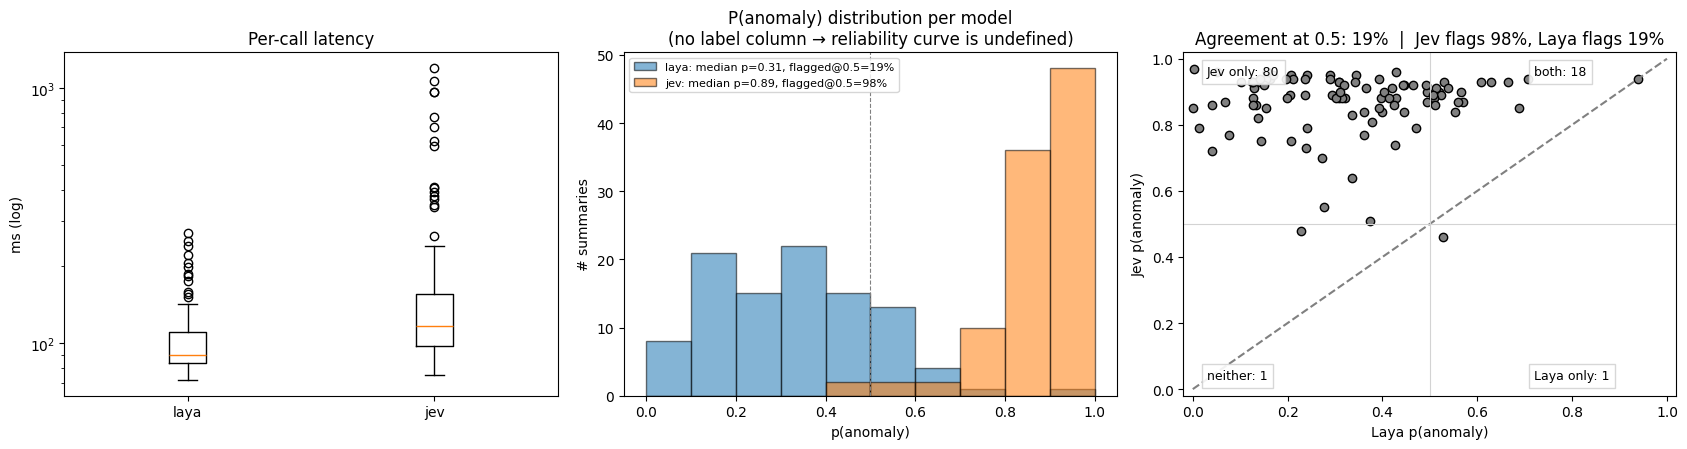

In [30]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

order = list(METHODS)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# 1. Per-call latency
axes[0].boxplot([results[results.method == m].latency_ms.dropna() for m in order])
axes[0].set_xticks(range(1, len(order) + 1))
axes[0].set_xticklabels(order)
axes[0].set_yscale("log")
axes[0].set_ylabel("ms (log)")
axes[0].set_title("Per-call latency")

# 2. Reliability (needs labels) — otherwise show what each model actually outputs
if HAS_LABELS:
    axes[1].plot([0, 1], [0, 1], "--", color="grey", label="perfect calibration")
    for m in order:
        g = results[results.method == m].dropna(subset=["p_anomaly"])
        try:
            fp, mp = calibration_curve(g.label.astype(int), g.p_anomaly,
                                       n_bins=min(4, max(2, len(g) // 3)), strategy="quantile")
            axes[1].plot(mp, fp, "o-", label=m)
        except Exception as e:
            print("reliability skipped for", m, ":", e)
    axes[1].set_xlabel("predicted p(anomaly)")
    axes[1].set_ylabel("observed anomaly rate")
    axes[1].set_title("Reliability (noisy at this n)")
else:
    bins = np.linspace(0, 1, 11)
    for m in order:
        p = results[results.method == m].p_anomaly.dropna()
        axes[1].hist(p, bins=bins, alpha=0.55, edgecolor="k",
                     label=f"{m}: median p={p.median():.2f}, flagged@0.5={(p >= .5).mean():.0%}")
    axes[1].axvline(0.5, color="grey", lw=0.8, ls="--")
    axes[1].set_xlabel("p(anomaly)")
    axes[1].set_ylabel("# summaries")
    axes[1].set_title("P(anomaly) distribution per model\n(no label column → reliability curve is undefined)")
axes[1].legend(fontsize=8)

# 3. Laya vs Jev agreement, with the numbers spelled out
lx, jy = wide["laya"], wide["jev"]
both  = int(((lx >= .5) & (jy >= .5)).sum())
none_ = int(((lx <  .5) & (jy <  .5)).sum())
jev_only  = int(((lx <  .5) & (jy >= .5)).sum())
laya_only = int(((lx >= .5) & (jy <  .5)).sum())
agree = (both + none_) / len(wide)

if HAS_LABELS:
    axes[2].scatter(lx, jy, c=cases_df.label.fillna(0.5).values, cmap="coolwarm", edgecolor="k")
else:
    axes[2].scatter(lx, jy, color="grey", edgecolor="k")
axes[2].plot([0, 1], [0, 1], "--", color="grey")
axes[2].axhline(.5, color="lightgrey", lw=.8)
axes[2].axvline(.5, color="lightgrey", lw=.8)
for (x, y, txt) in [(.03, .95, f"Jev only: {jev_only}"), (.72, .95, f"both: {both}"),
                    (.03, .03, f"neither: {none_}"),   (.72, .03, f"Laya only: {laya_only}")]:
    axes[2].text(x, y, txt, fontsize=9, bbox=dict(fc="white", ec="lightgrey", alpha=.9))
axes[2].set_xlim(-.02, 1.02); axes[2].set_ylim(-.02, 1.02)
axes[2].set_xlabel("Laya p(anomaly)")
axes[2].set_ylabel("Jev p(anomaly)")
axes[2].set_title(f"Agreement at 0.5: {agree:.0%}  |  Jev flags {(jy >= .5).mean():.0%}, Laya flags {(lx >= .5).mean():.0%}"
                  + ("\n(red = true anomaly)" if HAS_LABELS else ""))

plt.tight_layout()
plt.show()

## 11. Where do they disagree

In [25]:
cmp = cases_df[["label", "exp_type"]].copy()
cmp["case"] = [as_text(c["state"]["discharge_summary"]).replace("\n", " ")[:140] + "…" for c in CASES]
for m in METHODS:
    sub = results[results.method == m].reset_index(drop=True)
    cmp[f"p_{m}"] = sub.p_anomaly.round(3); cmp[f"type_{m}"] = sub.type; cmp[f"sev_{m}"] = sub.severity

flag = ((cmp.p_laya >= .5) != (cmp.p_jev >= .5)) | ((cmp.p_laya - cmp.p_jev).abs() > .4)
if HAS_LABELS:
    cmp["laya_wrong"] = (cmp.p_laya >= .5).astype(int) != cmp.label
    cmp["jev_wrong"]  = (cmp.p_jev  >= .5).astype(int) != cmp.label
    flag |= cmp.laya_wrong | cmp.jev_wrong
pd.set_option("display.max_colwidth", 120)
print(f"{int(flag.sum())} flagged of {len(cmp)}")
display(cmp[flag])
print(f"Severity agreement (Laya vs Jev): {(cmp.sev_laya == cmp.sev_jev).mean():.0%}")


82 flagged of 100


,label,exp_type,case,p_laya,type_laya,sev_laya,p_jev,type_jev,sev_jev
0,NaN,None,"0, 1-IDENTIFY THE CASEES OF ILLNESS BY DOING INVESTIGATIONS 2- TO RELEIVE A known case of DM was presented for follo...",0.362,unsafe_discharge,low,0.77,documentation_inconsistency,low
1,NaN,None,"0307257680 - Enoxert amp 1 mg IV, 10-149-91 - normal saline, 110103 - I.V INJECTION, 110106 - ER ROOM FEE (OBSERVATI...",0.205,medication_error,high,0.89,documentation_inconsistency,high
2,NaN,None,"0509222585 - PANADOL COLD & FLU CAPLET, 11-212-92 - KAFOSED SYRUP 15MG-5ML, days-supply 24 d, last-menstrual-period,...",0.003,unsafe_discharge,low,0.97,documentation_inconsistency,critical
3,NaN,None,"0509222585 - PANADOL COLD & FLU CAPLET, 2-5938-24 - MUCOSOLVAN TAB 30MG, fever / productive cough / sore throat /// ...",0.158,unsafe_discharge,moderate,0.95,documentation_inconsistency,critical
4,NaN,None,"0509222585 - PANADOL COLD & FLU CAPLET, 3107222372 - AMBOLAR SYRUP, vital-sign-diastolic 120 mm[Hg], last-menstrual-...",0.156,unsafe_discharge,moderate,0.96,documentation_inconsistency,critical
...,...,...,...,...,...,...,...,...,...
93,NaN,None,"17.5 kg, chief-complaint fever cough runny nose-, respiratory-rate 14 /min, S1 +S2//Lax//harsh breathing, vital-sign...",0.336,unsafe_discharge,low,0.83,documentation_inconsistency,low
95,NaN,None,"17 kg, chief-complaint FEVER, pain in the pharynx, difficulty swallowing, runny nose, snoring, sneezing, and headach...",0.273,none,none,0.70,documentation_inconsistency,moderate
96,NaN,None,"187-325-07 - AZIMAC 500 mg, 10-444-04 - EMIDOL 500MG TABLET, 17-212-94 - EXYLIN SYRUP 14MG-5ML, temperature 39 ?°C, ...",0.142,unsafe_discharge,high,0.94,documentation_inconsistency,high
97,NaN,None,"1, 89 kg, NA, vital-sign-systolic 130 mm[Hg], days-supply 5 d, pulse 99 /min, Normal, respiratory-rate 15 /min, chie...",0.199,unsafe_discharge,moderate,0.88,documentation_inconsistency,high


Severity agreement (Laya vs Jev): 32%


## 12. Confidence gating


In [26]:
if HAS_LABELS:
    rows = []
    for m in METHODS:
        g = results[results.method == m].dropna(subset=["p_anomaly"])
        y, p = g.label.astype(int).values, g.p_anomaly.values
        margin = np.abs(p - .5) * 2
        for thr in np.linspace(0, .9, 10):
            k = margin >= thr
            if k.sum() == 0: break
            rows.append({"method": m, "min_margin": round(thr, 2), "coverage": k.mean(),
                         "accuracy_on_covered": ((p[k] >= .5).astype(int) == y[k]).mean()})
    gate = pd.DataFrame(rows)
    display(gate.pivot(index="min_margin", columns="method", values=["coverage", "accuracy_on_covered"]).round(3))
    plt.figure(figsize=(5.5, 3.8))
    for m in METHODS:
        g = gate[gate.method == m]; plt.plot(g.coverage, g.accuracy_on_covered, "o-", label=m)
    plt.xlabel("coverage (fraction auto-decided)"); plt.ylabel("accuracy on auto-decided"); plt.title("Coverage vs accuracy")
    plt.grid(alpha=.3); plt.legend(); plt.show()
else:
    print("Skipped: no label column.")


Skipped: no label column.


## 13. Stability (repeats a few cases; costs a handful of extra Jev calls)

In [27]:
N_REPEAT, SAMPLE = 3, CASES[::max(1, len(CASES)//4)][:4]
stab = []
for name in METHODS:
    for i, c in enumerate(SAMPLE):
        ps = [METHODS[name](c)["p_anomaly"] for _ in range(N_REPEAT)]
        stab.append({"method": name, "case": i, "std": float(np.std(ps)), "range": max(ps) - min(ps)})
display(pd.DataFrame(stab).groupby("method")[["std", "range"]].mean().round(4))


,std,range
method,,
jev,0.0055,0.0125
laya,0.0000,0.0000


## 14. Save

In [28]:
OUT_DIR = "/content" if os.path.isdir("/content") else "."
results.to_csv(f"{OUT_DIR}/laya_vs_jev_results.csv", index=False)
score.to_csv(f"{OUT_DIR}/laya_vs_jev_scoreboard.csv")
print("Saved", f"{OUT_DIR}/laya_vs_jev_results.csv", "and", f"{OUT_DIR}/laya_vs_jev_scoreboard.csv")
try:
    from google.colab import files
    files.download(f"{OUT_DIR}/laya_vs_jev_results.csv")
except Exception:
    pass


Saved /content/laya_vs_jev_results.csv and /content/laya_vs_jev_scoreboard.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>